# Week 9 – Day 1 Lab
## Stable Diffusion: Text-to-Image Generation

### Objectives

By the end of this lab, you will:
- Generate images using Stable Diffusion.
- Understand how prompts influence image generation.
- Experiment with inference steps, CFG scale, and random seeds.
- Build a mini AI-generated image gallery.


# Step 1: Enable GPU Runtime

Stable Diffusion requires significant computational power to generate images efficiently. Google Colab provides free access to GPUs, which can greatly speed up image generation.

Before proceeding, switch your notebook to use a GPU.

### Instructions

1. Click **Runtime** in the top menu.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, choose **T4 GPU** (or any available GPU).
4. Click **Save**.

### Verify that the GPU is Available

Run the code cell below to check whether your notebook is connected to a GPU. If the GPU is available, the output should display the name of the GPU (e.g., NVIDIA Tesla T4).

In [4]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is not available. Please enable GPU from Runtime → Change runtime type.")

✅ GPU is available!
GPU Name: Tesla T4


# Step 2: Install Required Libraries

Stable Diffusion is not included in Google Colab by default, so we first need to install the required Python libraries.

The following packages will be installed:

- **diffusers** – Provides Stable Diffusion models.
- **transformers** – Used for text encoding.
- **accelerate** – Optimizes model execution.
- **safetensors** – Secure model loading.

Run the following cell to install these packages.

In [5]:
!pip install -q diffusers transformers accelerate safetensors

# Step 3: Import Required Libraries

Now that the required packages are installed, we need to import them into our notebook.

We will use:

- **torch** for tensor computations.
- **StableDiffusionPipeline** to load the pre-trained model.
- **matplotlib** to display generated images.

Run the following cell.

In [7]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

#Load the Stable Diffusion Model

Stable Diffusion is a pre-trained generative AI model capable of converting text descriptions into images.

In this step, we will load the model and prepare it for image generation.

**Note:** The first execution may take several minutes because the model needs to be downloaded.


Hints:

- Use StableDiffusionPipeline.from_pretrained()
- The model name is:
  runwayml/stable-diffusion-v1-5
- Move the pipeline to the GPU.

In [8]:
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Generate Your First AI Image

Let's generate your first AI image!



Complete the code below to generate an image for the following prompt:

> "A futuristic city at sunset"

Display the generated image.

  0%|          | 0/50 [00:00<?, ?it/s]

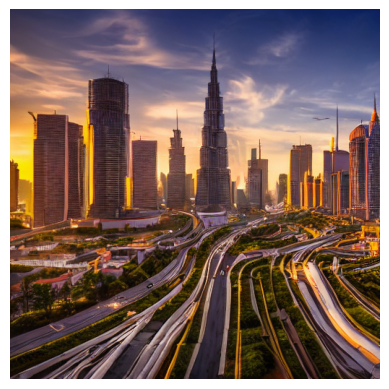

In [13]:
prompt = "A futuristic city at sunset"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis('off')
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

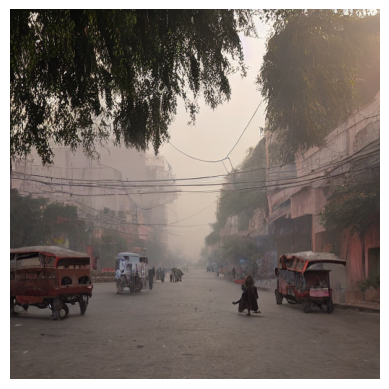

In [21]:
prompt = "Lahore at dawn"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis('off')
plt.show()

# Experiment 1: Prompt Engineering

The quality of an AI-generated image depends greatly on the prompt.

Generate images using both prompts below.

### Prompt 1

Dog

### Prompt 2

A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography



generate both images.

  0%|          | 0/50 [00:00<?, ?it/s]

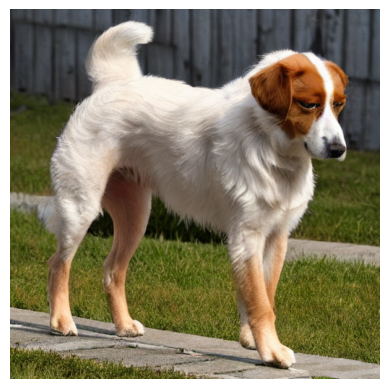

In [22]:
prompt = "Dog"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis('off')
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

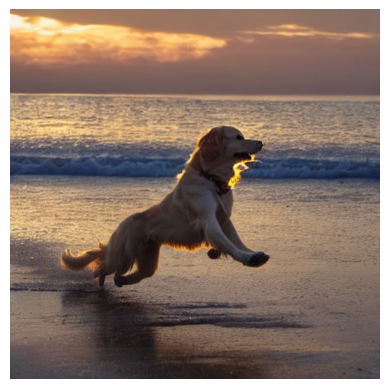

In [25]:
prompt = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis('off')
plt.show()

## Reflection

1. Which prompt generated the better image?

2. Which image contained more details?

3. Why do detailed prompts usually produce better results?

In [28]:
print("Which prompt generated the better image?")
print("Prompt 2 : It correctly matched the breed, setting, sunset, and motion described.")

print("\n2. Which image contained more details?")
print("Prompt 2 — full scene with beach, waves, sunset lighting, and a dynamic pose, vs. just a dog standing on grass.")

print("\n3. Why do detailed prompts usually produce better results?")
print("Detailed prompts give the model concrete targets (breed, setting, lighting, style) to steer generation toward, instead of leaving it to guess a generic default.")

Which prompt generated the better image?
Prompt 2 : It correctly matched the breed, setting, sunset, and motion described.

2. Which image contained more details?
Prompt 2 — full scene with beach, waves, sunset lighting, and a dynamic pose, vs. just a dog standing on grass.

3. Why do detailed prompts usually produce better results?
Detailed prompts give the model concrete targets (breed, setting, lighting, style) to steer generation toward, instead of leaving it to guess a generic default.


# Experiment 2: Inference Steps

Stable Diffusion gradually removes noise over multiple iterations.

These iterations are called **Inference Steps**.


Generate the same image using:

- 20 inference steps
- 50 inference steps

  0%|          | 0/20 [00:00<?, ?it/s]

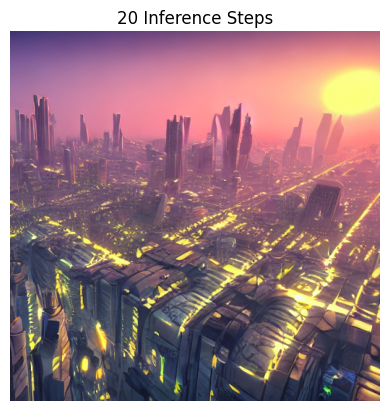

In [29]:
prompt = "A futuristic city at sunset"

image_20 = pipe(prompt, num_inference_steps=20).images[0]
plt.imshow(image_20)
plt.axis("off")
plt.title("20 Inference Steps")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

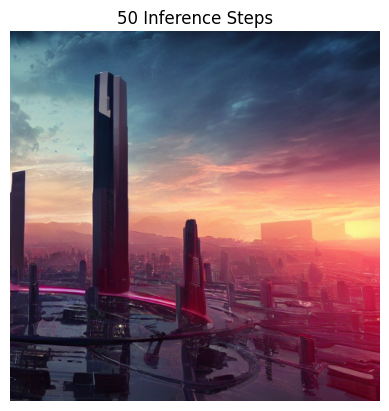

In [30]:
prompt = "A futuristic city at sunset"

image_50 = pipe(prompt, num_inference_steps=50).images[0]
plt.imshow(image_50)
plt.axis("off")
plt.title("50 Inference Steps")
plt.show()

## Reflection

- Which image looks sharper?

- Was there a noticeable improvement?

- Did image generation take longer?

In [31]:
print("Q: Which image looks sharper?")
print("A: The 50-step image — buildings have crisper edges and more defined architectural detail, with more nuanced sky gradients.")

print("\nQ: Was there a noticeable improvement?")
print("A: Some — the 50-step version looks more refined and less painterly, but the 20-step image was already coherent and strong. The improvement was modest, not dramatic.")

print("\nQ: Did image generation take longer?")
print("A: Only slightly — both ran at similar speed (~7s, ~7 it/s), but 50 steps took a bit longer overall since it's proportionally more iterations.")

Q: Which image looks sharper?
A: The 50-step image — buildings have crisper edges and more defined architectural detail, with more nuanced sky gradients.

Q: Was there a noticeable improvement?
A: Some — the 50-step version looks more refined and less painterly, but the 20-step image was already coherent and strong. The improvement was modest, not dramatic.

Q: Did image generation take longer?
A: Only slightly — both ran at similar speed (~7s, ~7 it/s), but 50 steps took a bit longer overall since it's proportionally more iterations.


# Experiment 3: Guidance Scale (CFG)

CFG controls how closely Stable Diffusion follows your prompt.


Generate the same prompt using:

- CFG = 5
- CFG = 8
- CFG = 12



  0%|          | 0/50 [00:00<?, ?it/s]

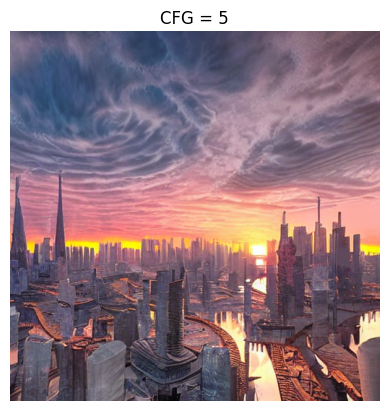

In [32]:
prompt = "A futuristic city at sunset"

image_cfg5 = pipe(prompt, guidance_scale=5).images[0]
plt.imshow(image_cfg5)
plt.axis("off")
plt.title("CFG = 5")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

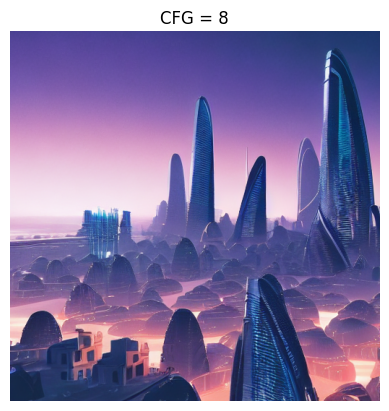

In [33]:
image_cfg8 = pipe(prompt, guidance_scale=8).images[0]
plt.imshow(image_cfg8)
plt.axis("off")
plt.title("CFG = 8")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

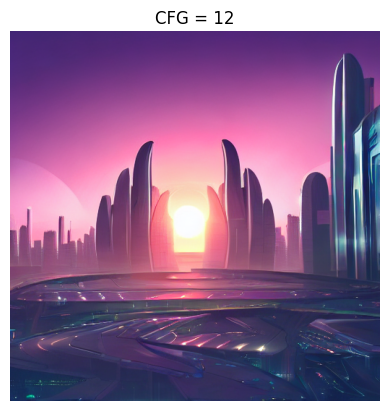

In [34]:
image_cfg12 = pipe(prompt, guidance_scale=12).images[0]
plt.imshow(image_cfg12)
plt.axis("off")
plt.title("CFG = 12")
plt.show()

## Reflection

- Which CFG value produced the best image?

- Which image followed the prompt most accurately?

- What happens when CFG becomes too high?

In [36]:
print("Q: Which CFG value produced the best image?")
print("A: CFG = 8 — it strikes the best balance, with a well-composed futuristic skyline that's detailed without looking distorted or over-processed.")

print("\nQ: Which image followed the prompt most accurately?")
print("A: CFG = 12 — it most strongly emphasizes the 'sunset' element with a bold, saturated sun glow, and pushes the futuristic city styling harder, sticking closest to the literal prompt.")

print("\nQ: What happens when CFG becomes too high?")
print("A: The image starts looking oversaturated and less naturalistic — colors intensify, contrast increases, and the composition can start to feel exaggerated or artificial rather than photorealistic.")

Q: Which CFG value produced the best image?
A: CFG = 8 — it strikes the best balance, with a well-composed futuristic skyline that's detailed without looking distorted or over-processed.

Q: Which image followed the prompt most accurately?
A: CFG = 12 — it most strongly emphasizes the 'sunset' element with a bold, saturated sun glow, and pushes the futuristic city styling harder, sticking closest to the literal prompt.

Q: What happens when CFG becomes too high?
A: The image starts looking oversaturated and less naturalistic — colors intensify, contrast increases, and the composition can start to feel exaggerated or artificial rather than photorealistic.


# Experiment 4: Random Seed

Every image starts from random noise.

Changing the seed changes the starting noise, resulting in different images.



Complete the code below.

Generate images using the following seeds:

- 42
- 100
- 500



  0%|          | 0/50 [00:00<?, ?it/s]

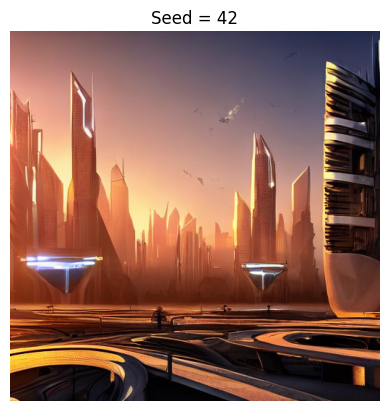

In [37]:
prompt = "A futuristic city at sunset"

generator = torch.Generator("cuda").manual_seed(42)
image_seed42 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed42)
plt.axis("off")
plt.title("Seed = 42")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

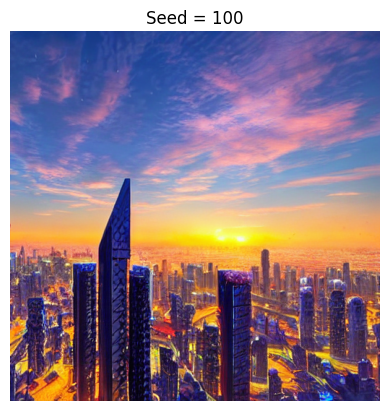

In [38]:
generator = torch.Generator("cuda").manual_seed(100)
image_seed100 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed100)
plt.axis("off")
plt.title("Seed = 100")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

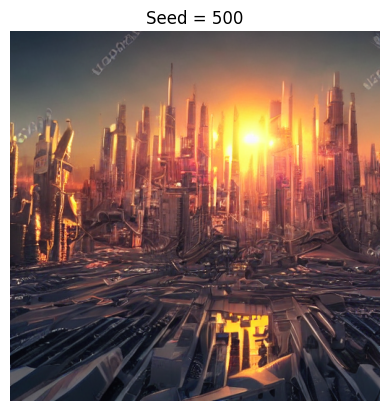

In [39]:
generator = torch.Generator("cuda").manual_seed(500)
image_seed500 = pipe(prompt, generator=generator).images[0]
plt.imshow(image_seed500)
plt.axis("off")
plt.title("Seed = 500")
plt.show()

## Reflection

- Which seed generated your favorite image?

- What changed when the seed changed?

- Why are seeds useful when reproducing results?

In [41]:
print("Q: Which seed generated your favorite image?")
print("A: Seed = 500 — it has the most dramatic composition, with a wide aerial view, strong warm sunset glow, and layered city detail stretching into the distance.")

print("Q: \nWhat changed when the seed changed?")
print("A: The overall scene changed completely each time — camera angle, building layout, color palette, and time-of-day lighting all shifted, even though the prompt stayed identical. \nSeed 42 leaned orange/warm with a street-level view, seed 100 had a blue-purple sky with a tall central tower, and seed 500 had a golden aerial cityscape.")

print("Q: \nWhy are seeds useful when reproducing results?")
print("A: A fixed seed controls the initial random noise the diffusion process starts from, so using the same seed with the same prompt and settings will always regenerate the exact same image, \nuseful for testing changes to other parameters (like CFG or steps) in a controlled, reproducible way.")

Q: Which seed generated your favorite image?
A: Seed = 500 — it has the most dramatic composition, with a wide aerial view, strong warm sunset glow, and layered city detail stretching into the distance.
Q: 
What changed when the seed changed?
A: The overall scene changed completely each time — camera angle, building layout, color palette, and time-of-day lighting all shifted, even though the prompt stayed identical. 
Seed 42 leaned orange/warm with a street-level view, seed 100 had a blue-purple sky with a tall central tower, and seed 500 had a golden aerial cityscape.
Q: 
Why are seeds useful when reproducing results?
A: A fixed seed controls the initial random noise the diffusion process starts from, so using the same seed with the same prompt and settings will always regenerate the exact same image, 
useful for testing changes to other parameters (like CFG or steps) in a controlled, reproducible way.
